# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yasmeenmh90-beep/flyrank-ml-internship-starter/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
from google.colab import userdata
import os, subprocess, sys
token = userdata.get("HF_TOKEN")
assert token, "Add HF_TOKEN to Colab Secrets first."
repo = "flyrank-ml-internship-starter"
if not os.path.isdir(repo):
    subprocess.run(["git","clone","--depth","1","https://github.com/yasmeenmh90-beep/flyrank-ml-internship-starter",repo],check=True)
os.chdir(repo)
%pip -q install duckdb huggingface_hub
import duckdb, pandas as pd, numpy as np, matplotlib.pyplot as plt
con=duckdb.connect()
safe_token = token.replace("'", "''")
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{safe_token}')")
MONTH="2026-03"
fact_month=f"read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month={MONTH}/*.parquet')"
print("Connected:",MONTH)


Connected: 2026-03


## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 92548 Decline rate: 0.28643514716687557


,imp_first_half,ctr,pos_first_half,pageviews_first_half,engagement_rate
count,92548.000000,92548.000000,92548.000000,92548.000000,32954.000000
mean,1368.890478,0.002867,13.770436,6.583805,0.027722
std,3323.195417,0.005337,14.190372,25.302811,0.106238
min,50.000000,0.000000,0.000000,0.000000,0.000000
50%,406.000000,0.000675,8.065899,0.000000,0.000000
90%,3242.000000,0.008130,32.811266,16.000000,0.063432
95%,5619.950000,0.012121,43.467498,35.000000,0.142857
99%,14891.970000,0.023529,69.459231,102.000000,0.500000
max,161575.000000,0.213592,127.620709,1270.000000,1.000000


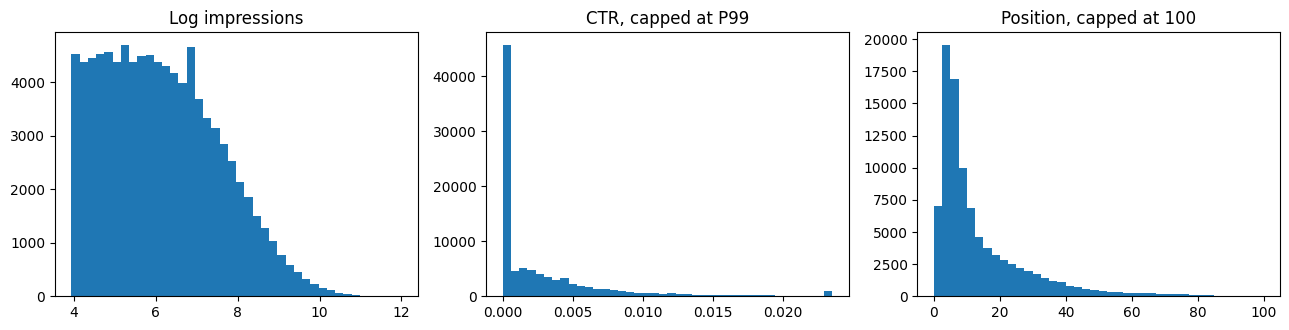

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

features=con.sql(f"""
SELECT client_hash_id, content_hash_id,
SUM(CASE WHEN report_date <= DATE '2026-03-15' THEN gsc_impressions ELSE 0 END) imp_first_half,
SUM(CASE WHEN report_date > DATE '2026-03-15' THEN gsc_impressions ELSE 0 END) imp_second_half,
SUM(CASE WHEN report_date <= DATE '2026-03-15' THEN gsc_clicks ELSE 0 END) clicks_first_half,
AVG(CASE WHEN report_date <= DATE '2026-03-15' THEN gsc_avg_position END) pos_first_half,
SUM(CASE WHEN report_date <= DATE '2026-03-15' THEN ga4_pageviews ELSE 0 END) pageviews_first_half,
SUM(CASE WHEN report_date <= DATE '2026-03-15' THEN ga4_engaged_sessions ELSE 0 END) engaged_first_half,
BOOL_OR(CASE WHEN report_date <= DATE '2026-03-15' THEN COALESCE(ga4_data_available,FALSE) ELSE FALSE END) ga4_available
FROM {fact_month}
GROUP BY 1,2 HAVING imp_first_half >= 50
""").df()
features["declined"]=(features.imp_second_half < .8*features.imp_first_half).astype(int)
features["ctr"]=features.clicks_first_half/features.imp_first_half
features["engagement_rate"]=np.where(features.pageviews_first_half>0,features.engaged_first_half/features.pageviews_first_half,np.nan)
print("Rows:",len(features),"Decline rate:",features.declined.mean())
display(features[["imp_first_half","ctr","pos_first_half","pageviews_first_half","engagement_rate"]].describe(percentiles=[.5,.9,.95,.99]))
fig,axes=plt.subplots(1,3,figsize=(13,3.4))
axes[0].hist(np.log1p(features.imp_first_half),bins=40);axes[0].set_title("Log impressions")
axes[1].hist(features.ctr.clip(upper=features.ctr.quantile(.99)),bins=40);axes[1].set_title("CTR, capped at P99")
axes[2].hist(features.pos_first_half.dropna().clip(upper=100),bins=40);axes[2].set_title("Position, capped at 100")
plt.tight_layout();plt.show()


## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

SIGNAL 1: Position vs CTR


,bucket,n,ctr
0,4-10,681601,0.003309
1,21+,396021,0.001342
2,1-3,332341,0.004267
3,11-20,230274,0.003334


SIGNAL 2: Volume vs later decline


,n,decline_rate
volume_quartile,,
Q1,23208,0.291580
Q2,23115,0.291413
Q3,23098,0.273054
Q4,23127,0.289661


SIGNAL 3: Engagement vs later decline


,n,decline_rate
engagement_bucket,,
30% or above,791,0.166877
Below 30%,32163,0.261512


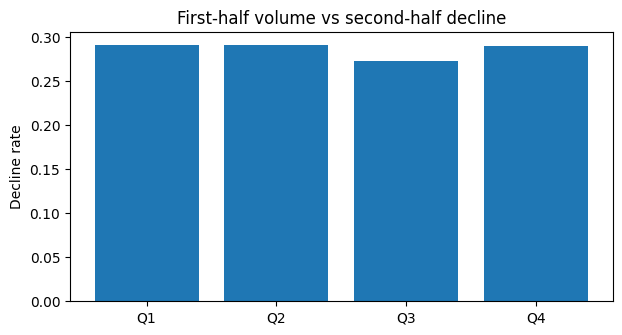

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

s1=con.sql(f"""
SELECT CASE WHEN gsc_avg_position<=3 THEN '1-3'
WHEN gsc_avg_position<=10 THEN '4-10'
WHEN gsc_avg_position<=20 THEN '11-20' ELSE '21+' END bucket,
COUNT(*) n, SUM(gsc_clicks)*1.0/NULLIF(SUM(gsc_impressions),0) ctr
FROM {fact_month}
WHERE report_date <= DATE '2026-03-15' AND gsc_impressions>0
GROUP BY 1
""").df()
print("SIGNAL 1: Position vs CTR");display(s1)
features["volume_quartile"]=pd.qcut(features.imp_first_half,4,labels=["Q1","Q2","Q3","Q4"])
s2=features.groupby("volume_quartile",observed=True).agg(n=("declined","size"),decline_rate=("declined","mean"))
print("SIGNAL 2: Volume vs later decline");display(s2)
ga=features[features.ga4_available.fillna(False)&features.engagement_rate.notna()].copy()
ga["engagement_bucket"]=np.where(ga.engagement_rate<.30,"Below 30%","30% or above")
s3=ga.groupby("engagement_bucket").agg(n=("declined","size"),decline_rate=("declined","mean"))
print("SIGNAL 3: Engagement vs later decline");display(s3)
fig,ax=plt.subplots(figsize=(7,3.5))
ax.bar(s2.index.astype(str),s2.decline_rate)
ax.set_ylabel("Decline rate");ax.set_title("First-half volume vs second-half decline")
plt.show()


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

p75=features.imp_first_half.quantile(.75)
features["flag"]=(features.pos_first_half>20)&(features.imp_first_half>=p75)
result=features.groupby("flag").agg(n=("declined","size"),decline_rate=("declined","mean"),median_impressions=("imp_first_half","median"))
print("POOR_POSITION_HIGH_VOLUME — flag-linked retrospective test")
display(result)
print("Interpret cautiously: association is not causality, and outcome coverage may differ.")


POOR_POSITION_HIGH_VOLUME — flag-linked retrospective test


,n,decline_rate,median_impressions
flag,,,
False,87638,0.276307,363.0
True,4910,0.467210,3176.5


Interpret cautiously: association is not causality, and outcome coverage may differ.


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


The signal audit identified useful but uneven evidence for content-review prioritization. Better search positions were associated with higher click-through rates, and higher engagement was associated with lower subsequent decline within the available GA4 subset. Impression volume alone showed a mixed relationship with decline.

The POOR_POSITION_HIGH_VOLUME flag identified 4,910 content items with a 46.72% observed decline rate, compared with 27.63% for unflagged items. This supports using the flag as a human-review prioritization signal, while acknowledging that the relationship is observational and may be affected by reporting coverage, client differences, and other confounding factors.

Content teams should use these findings to guide investigation rather than automatically trigger refresh actions. Future validation should test the signals on additional time periods and client-held-out datasets.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.